In [1]:
import datetime as dt
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import warnings
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error
from IPython.display import Image

In [2]:
pd.options.display.float_format = "{:,.2f}".format
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

In [8]:
energy = pd.read_csv("data/energy.csv")
energy.drop("temp", axis=1, inplace=True)
energy.set_index("timestamp", inplace=True)
energy.head(10)

,load
timestamp,
2012-01-01 00:00:00,"2,698.00"
2012-01-01 01:00:00,"2,558.00"
2012-01-01 02:00:00,"2,444.00"
2012-01-01 03:00:00,"2,402.00"
2012-01-01 04:00:00,"2,403.00"
2012-01-01 05:00:00,"2,453.00"
2012-01-01 06:00:00,"2,560.00"
2012-01-01 07:00:00,"2,719.00"
2012-01-01 08:00:00,"2,916.00"


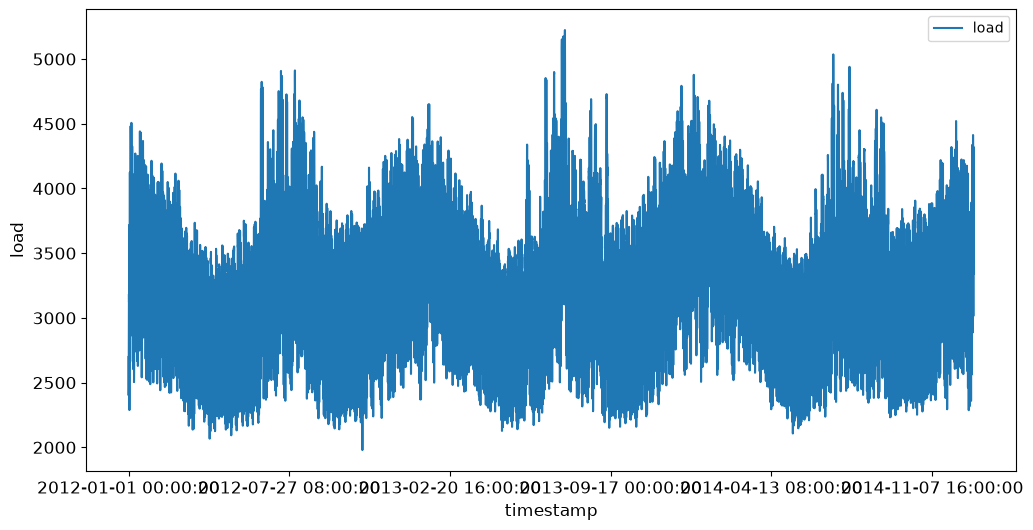

In [9]:
energy.plot(y="load", subplots=True, figsize=(12,6), fontsize=12)
plt.xlabel("timestamp", fontsize=12)
plt.ylabel("load", fontsize=12)
plt.show()

In [10]:
train_start_date = '2014-11-01 00:00:00'
test_start_date = '2014-12-30 00:00:00'

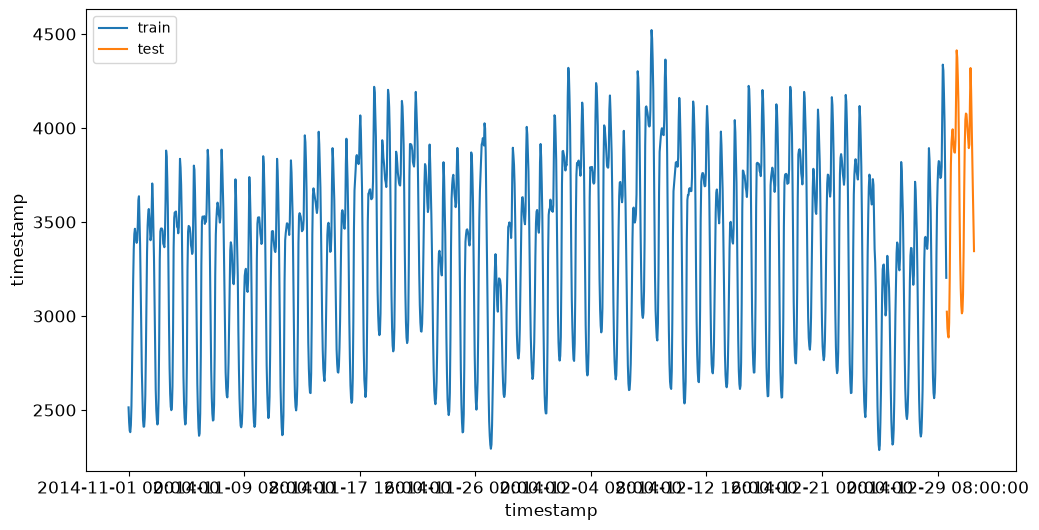

In [11]:
energy[(energy.index >= train_start_date) & (energy.index < test_start_date)][["load"]].rename(columns={"load" : "train"})\
    .join(energy[test_start_date:][["load"]].rename(columns={"load" : "test"}), how="outer")\
    .plot(y=["train", "test"], figsize=(12,6), fontsize=12)
plt.xlabel("timestamp", fontsize=12)
plt.ylabel("timestamp", fontsize=12)
plt.show()

In [12]:
train = energy[(energy.index >= train_start_date) & (energy.index < test_start_date)][["load"]]
train.shape

(1416, 1)

In [14]:
test = energy[(energy.index >= test_start_date)][["load"]]
test.shape

(48, 1)

In [15]:
scaler = MinMaxScaler()
train["load"] = scaler.fit_transform(train)
train.head()

,load
timestamp,
2014-11-01 00:00:00,0.10
2014-11-01 01:00:00,0.07
2014-11-01 02:00:00,0.05
2014-11-01 03:00:00,0.04
2014-11-01 04:00:00,0.06


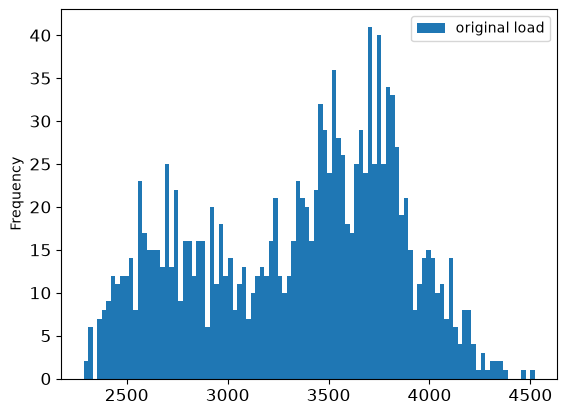

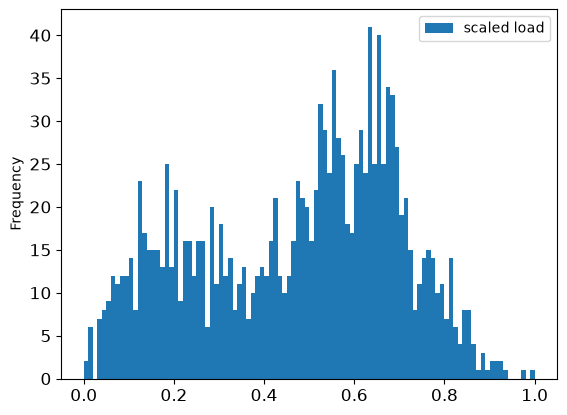

In [16]:
energy[(energy.index >= train_start_date) & (energy.index < test_start_date)][['load']].rename(columns={'load':'original load'}).plot.hist(bins=100, fontsize=12)
train.rename(columns={'load':'scaled load'}).plot.hist(bins=100, fontsize=12)
plt.show()

In [17]:
test["load"] = scaler.fit_transform(test)
test.head()

,load
timestamp,
2014-12-30 00:00:00,0.09
2014-12-30 01:00:00,0.03
2014-12-30 02:00:00,0.01
2014-12-30 03:00:00,0.00
2014-12-30 04:00:00,0.05
